In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OrdinalEncoder
import warnings
warnings.filterwarnings('ignore')


## 1 - Data Loading & Prep

Load the data, filter out `Open` from `Prospect_Outcome`, drop leaky features, encode categoricals.

In [2]:
project_root = Path.cwd()
while not (project_root / 'data').exists() and project_root != project_root.parent:
    project_root = project_root.parent

data_path = project_root / 'data' / 'processed' / 'model_ready_dataset.csv'
if not data_path.exists():
    data_path = Path(r'c:\Users\gokul\OneDrive\Desktop\dsmini\Churn-Prediction-JMAN\data\processed\model_ready_dataset.csv')

df = pd.read_csv(data_path)
print(f'Loaded shape: {df.shape}')

# Filter out Open category - only keep Won/Churned
df = df[df['Prospect_Outcome'].isin(['Won', 'Churned'])].copy()

# target: 1 = Churned, 0 = Won
df['target'] = (df['Prospect_Outcome'] == 'Churned').astype(int)
df.drop(columns=['Prospect_Outcome'], inplace=True)

# Drop leaky features identified in EDA
leaky_cols = [
    'Total_Net_Paid', 'price_change_pct', 'price_change_abs',
    'net_paid_vs_last', 'Payment_Method', 'Payment_Timeframe',
    'Days_To_Close_Post_Renewal', 'Total_Renewal_Score_New',
    'Renewal_Year'
]
df.drop(columns=leaky_cols, inplace=True, errors='ignore')

X = df.drop(columns=['target'])
y = df['target']

X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Encode categoricals
cat_cols = X_train_raw.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
if cat_cols:
    ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    train_enc_df = pd.DataFrame(ord_enc.fit_transform(X_train_raw[cat_cols]), columns=cat_cols, index=X_train_raw.index)
    test_enc_df  = pd.DataFrame(ord_enc.transform(X_test[cat_cols]), columns=cat_cols, index=X_test.index)
    X_train_raw = X_train_raw.drop(columns=cat_cols).join(train_enc_df)
    X_test      = X_test.drop(columns=cat_cols).join(test_enc_df)

X_train_raw = X_train_raw.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test      = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f'Class distribution in train: {dict(y_train_raw.value_counts())}')
print(f'Train size: {X_train_raw.shape[0]}, Test size: {X_test.shape[0]}, Features: {X_train_raw.shape[1]}')


Loaded shape: (122082, 61)


Class distribution in train: {0: np.int64(80981), 1: np.int64(10134)}
Train size: 91115, Test size: 22779, Features: 51


## 2 - SMOTE Oversampling

Apply SMOTE to balance the training data. We keep the original split too so we can compare with vs without SMOTE.

In [3]:
# Apply SMOTE to balance class distribution
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_raw, y_train_raw)
print(f'After SMOTE -> Train: {X_train_smote.shape[0]} rows, Churn rate: {y_train_smote.mean():.2%}')


After SMOTE -> Train: 161962 rows, Churn rate: 50.00%


## 3 - Hyperparameter Tuning (Grid Search)

GridSearchCV across `n_estimators`, `max_depth`, `criterion`, `min_samples_split` — run separately on SMOTE and non-SMOTE splits.

In [4]:
# Hyperparameter tuning with GridSearchCV for Random Forest
print('Running grid search on Random Forest...')

rf = RandomForestClassifier(random_state=42)

my_params = {
    'n_estimators': [10, 50],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 10],
    'criterion': ['gini', 'entropy']
}

grid_smote = GridSearchCV(rf, my_params, cv=3, scoring='f1')
grid_smote.fit(X_train_smote, y_train_smote)

grid_nosmote = GridSearchCV(RandomForestClassifier(random_state=42), my_params, cv=3, scoring='f1')
grid_nosmote.fit(X_train_raw, y_train_raw)

print('Best params (with SMOTE)   :', grid_smote.best_params_)
print('Best params (without SMOTE):', grid_nosmote.best_params_)


Running grid search on Random Forest...


Best params (with SMOTE)   : {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Best params (without SMOTE): {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}


## 4 - Train Final Models & Evaluate

Train two Random Forest models (with and without SMOTE) with the best params and compare on the test set.

In [5]:
# Train final random forest models using best hyperparameters

# -- With SMOTE --
rf_smote = RandomForestClassifier(**grid_smote.best_params_, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
preds_smote = rf_smote.predict(X_test)

# -- Without SMOTE --
rf_nosmote = RandomForestClassifier(**grid_nosmote.best_params_, random_state=42)
rf_nosmote.fit(X_train_raw, y_train_raw)
preds_nosmote = rf_nosmote.predict(X_test)

from sklearn.metrics import classification_report

print('===== WITH SMOTE =====')
print(f'ACC : {accuracy_score(y_test, preds_smote):.4f}')
print(f'Prec: {precision_score(y_test, preds_smote):.4f}')
print(f'Rec : {recall_score(y_test, preds_smote):.4f}')
print(f'F1  : {f1_score(y_test, preds_smote):.4f}')
print(classification_report(y_test, preds_smote, target_names=['Won', 'Churn']))

print('===== WITHOUT SMOTE =====')
print(f'ACC : {accuracy_score(y_test, preds_nosmote):.4f}')
print(f'Prec: {precision_score(y_test, preds_nosmote):.4f}')
print(f'Rec : {recall_score(y_test, preds_nosmote):.4f}')
print(f'F1  : {f1_score(y_test, preds_nosmote):.4f}')
print(classification_report(y_test, preds_nosmote, target_names=['Won', 'Churn']))


===== WITH SMOTE =====
ACC : 0.9079
Prec: 0.5563
Rec : 0.8516
F1  : 0.6730
              precision    recall  f1-score   support

         Won       0.98      0.91      0.95     20245
       Churn       0.56      0.85      0.67      2534

    accuracy                           0.91     22779
   macro avg       0.77      0.88      0.81     22779
weighted avg       0.93      0.91      0.92     22779

===== WITHOUT SMOTE =====
ACC : 0.9421
Prec: 0.9037
Rec : 0.5371
F1  : 0.6738
              precision    recall  f1-score   support

         Won       0.94      0.99      0.97     20245
       Churn       0.90      0.54      0.67      2534

    accuracy                           0.94     22779
   macro avg       0.92      0.76      0.82     22779
weighted avg       0.94      0.94      0.94     22779



## 5 - Confusion Matrix Comparison

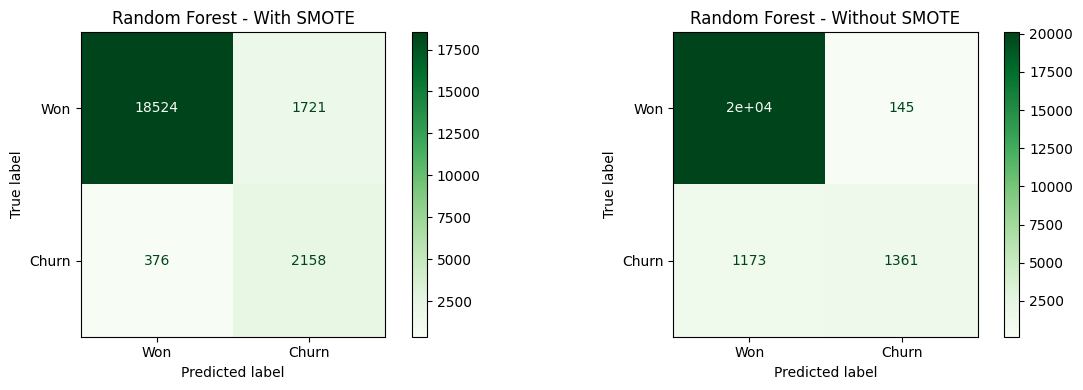

Summary comparison:
  With SMOTE    -> Rec: 0.852  Prec: 0.556  F1: 0.673
  Without SMOTE -> Rec: 0.537  Prec: 0.904  F1: 0.674


In [6]:
# Confusion matrix side-by-side comparison
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(
    axes,
    [preds_smote, preds_nosmote],
    ['Random Forest - With SMOTE', 'Random Forest - Without SMOTE']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Won', 'Churn'])
    disp.plot(cmap='Greens', ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

print('Summary comparison:')
print(f'  With SMOTE    -> Rec: {recall_score(y_test, preds_smote):.3f}  Prec: {precision_score(y_test, preds_smote):.3f}  F1: {f1_score(y_test, preds_smote):.3f}')
print(f'  Without SMOTE -> Rec: {recall_score(y_test, preds_nosmote):.3f}  Prec: {precision_score(y_test, preds_nosmote):.3f}  F1: {f1_score(y_test, preds_nosmote):.3f}')
